In [4]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load merged data from Phase 1
df = pd.read_csv("tsla_merged.csv", index_col='Date', parse_dates=True)
print(f"Loaded {len(df)} days of data")
print(df.columns)

Loaded 29675 days of data
Index(['tweet_text', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [8]:
from transformers import pipeline
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import textblob
import torch
import os

# Download VADER lexicon (run once)
nltk.download('vader_lexicon', quiet=True)

# Initialize sentiment tools
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=0 if torch.cuda.is_available() else -1)
vader = SentimentIntensityAnalyzer()

def get_finbert_sentiment(text):
    if not text or len(text.strip()) < 5:
        return 0.0
    try:
        result = finbert(text[:512])[0]  # truncate to 512 tokens
        score = result['score'] if result['label'] == 'positive' else -result['score']
        return score
    except:
        return 0.0

def get_vader_sentiment(text):
    if not text or len(text.strip()) < 5:
        return 0.0
    scores = vader.polarity_scores(text)
    return scores['compound']

def get_textblob_sentiment(text):
    if not text or len(text.strip()) < 5:
        return 0.0
    return textblob.TextBlob(text).sentiment.polarity

# Compute sentiment scores (this may take time - run on sample first)
print("Calculating sentiment scores...")

df['finbert_score'] = df['tweet_text'].apply(get_finbert_sentiment)
df['vader_score'] = df['tweet_text'].apply(get_vader_sentiment)
df['textblob_score'] = df['tweet_text'].apply(get_textblob_sentiment)

# Compare them
print("\nSentiment Score Statistics:")
print(df[['finbert_score', 'vader_score', 'textblob_score']].describe())
os.makedirs("results", exist_ok=True)
# Save intermediate result
df.to_csv("results/tsla_with_sentiment.csv")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Calculating sentiment scores...

Sentiment Score Statistics:
       finbert_score   vader_score  textblob_score
count   29675.000000  29675.000000    29675.000000
mean       -0.611644      0.151415        0.098310
std         0.560613      0.433512        0.246881
min        -0.976651     -0.993600       -1.000000
25%        -0.912971      0.000000        0.000000
50%        -0.854004      0.000000        0.000000
75%        -0.667453      0.493900        0.220422
max         0.959090      0.987100        1.000000


In [9]:
!pip install pandas-ta
# Technical Indicators
import pandas_ta as ta

# Price-based features
df['returns'] = df['Close'].pct_change()
df['log_returns'] = np.log(df['Close'] / df['Close'].shift(1))

# Technical indicators
df['sma_10'] = df['Close'].rolling(10).mean()
df['sma_20'] = df['Close'].rolling(20).mean()
df['rsi'] = ta.rsi(df['Close'], length=14)
df['macd'] = ta.macd(df['Close'])['MACD_12_26_9']
df['bb_upper'], df['bb_middle'], df['bb_lower'] = ta.bbands(df['Close']).iloc[:, :3].T.values
df['momentum_10'] = df['Close'] - df['Close'].shift(10)
df['volume_sma_10'] = df['Volume'].rolling(10).mean()

# Sentiment features
df['sentiment_vol_3'] = df['finbert_score'].rolling(3).std()   # 3-day sentiment volatility
df['sentiment_ma_5'] = df['finbert_score'].rolling(5).mean()

# Forward returns (for supervised learning)
for horizon in [1, 3, 7, 14]:
    df[f'fwd_return_{horizon}'] = df['Close'].shift(-horizon) / df['Close'] - 1

# Drop rows with NaN
df.dropna(inplace=True)

print(f"Final dataset shape: {df.shape}")
print(df.columns.tolist())

# Save final engineered dataset
df.to_csv("results/tsla_engineered_final.csv")

Final dataset shape: (29550, 26)
['tweet_text', 'Open', 'High', 'Low', 'Close', 'Volume', 'returns', 'log_returns', 'sma_10', 'sma_20', 'rsi', 'macd', 'bb_upper', 'bb_middle', 'bb_lower', 'momentum_10', 'volume_sma_10', 'finbert_score', 'vader_score', 'textblob_score', 'sentiment_vol_3', 'sentiment_ma_5', 'fwd_return_1', 'fwd_return_3', 'fwd_return_7', 'fwd_return_14']


<Figure size 1200x600 with 0 Axes>

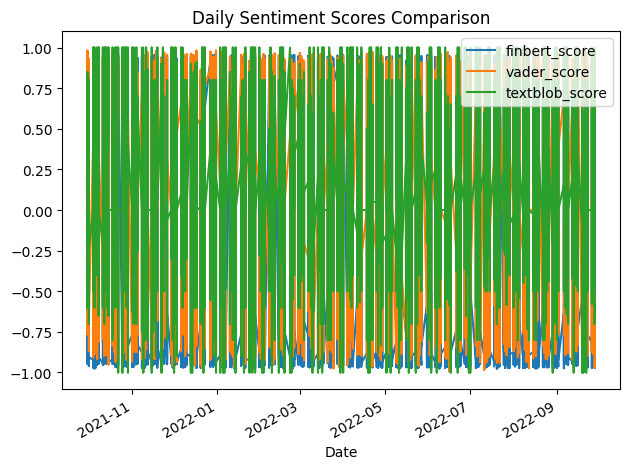


Correlation with next-day return:
finbert_score     0.001686
vader_score       0.002013
textblob_score   -0.000525
fwd_return_1      1.000000
Name: fwd_return_1, dtype: float64


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
df[['finbert_score', 'vader_score', 'textblob_score']].plot(title="Daily Sentiment Scores Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("results/sentiment_comparison.png")
plt.show()

# Correlation with next day return
print("\nCorrelation with next-day return:")
print(df[['finbert_score', 'vader_score', 'textblob_score', 'fwd_return_1']].corr()['fwd_return_1'])